In [1]:
from SCFT_DNA.SCFT_functions import *
from SCFT_DNA.DNA_input import *

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import hictkpy as htk
from matplotlib.colors import LogNorm

from pathlib import Path

from Bead_sequence_MC.mf_chromatin_functions import *

Using cupy


In [3]:
#ChiNpp = np.array([50, 100, 150, 200, 250, 300, 325, 350, 400, 450])
#ChiNps = np.array([50, 100, 150, 200, 250, 300, 325, 350, 400, 450])
ChiNpp = np.array([200, 250, 300, 325, 350, 400, 450, 500, 550])
ChiNps = np.array([200, 250, 300, 325, 350, 400, 450])

In [2]:
phi_blocks_grid = np.load("../results_parameter_sweep_phi01/phi_blocks_grid.npy", allow_pickle=True)
print(phi_blocks_grid.shape)

(9, 7)


In [7]:
phi_block_pick = phi_blocks_grid[8, 5]#[4,6]
del phi_blocks_grid

In [4]:
def imshow_grid(arrays, cmap=None, vmin=None, vmax=None,
                figsize=None, interpolation="nearest"):
    arrays = np.asarray(arrays)

    nx, ny = arrays.shape   # arrays is (nx, ny, H, W) or (nx, ny, ...)
    ncols = nx                  # x-axis in the big plot
    nrows = ny                  # y-axis in the big plot

    if figsize is None:
        figsize = (1.6 * ncols, 1.6 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)

    for r in range(nrows):          # r = y index
        for c in range(ncols):      # c = x index
            ax = axes[-r-1, c]
            # Note the swapped indexing: arrays[c, r]
            img = np.sum(arrays[c, r], axis=0)
            ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, interpolation=interpolation)
            ax.set_axis_off()

    plt.subplots_adjust(wspace=0.02, hspace=0.02)
    return fig, axes

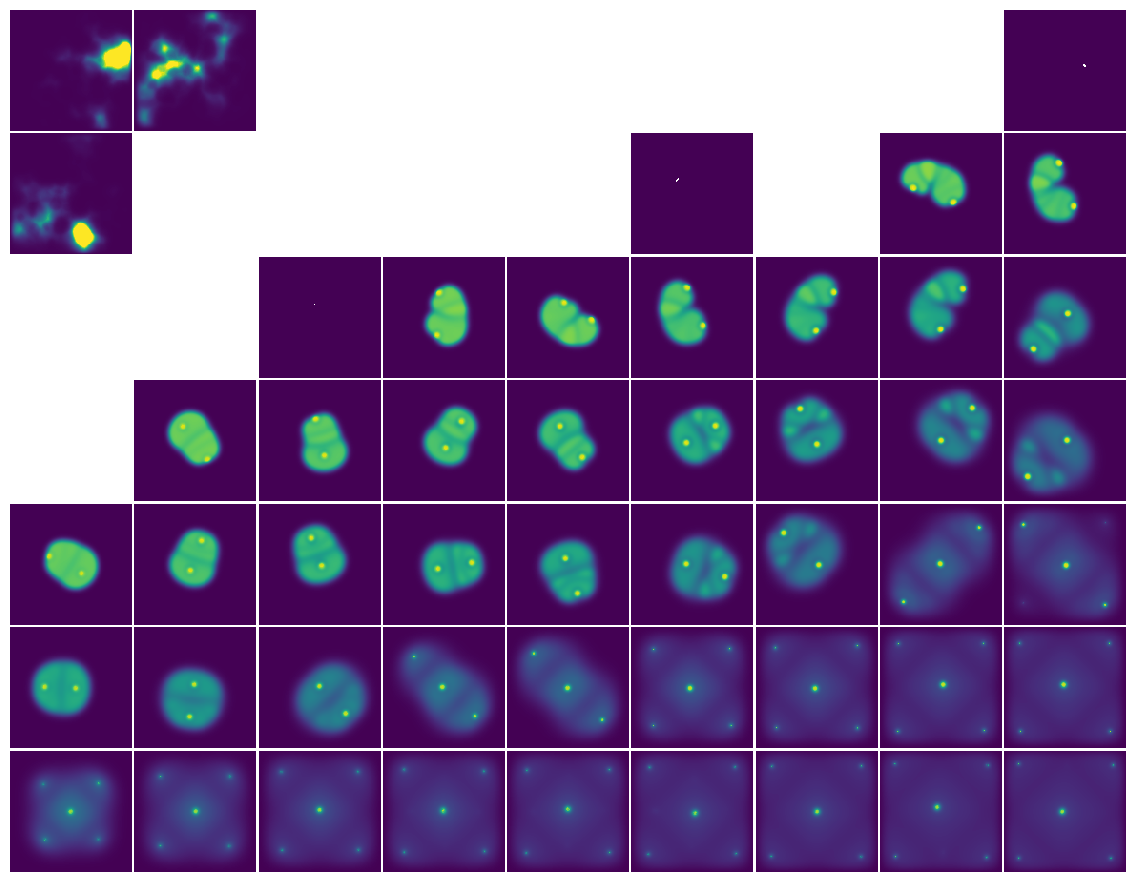

In [5]:
fig, axes = imshow_grid(phi_blocks_grid, vmin=0, vmax=1)
plt.show()

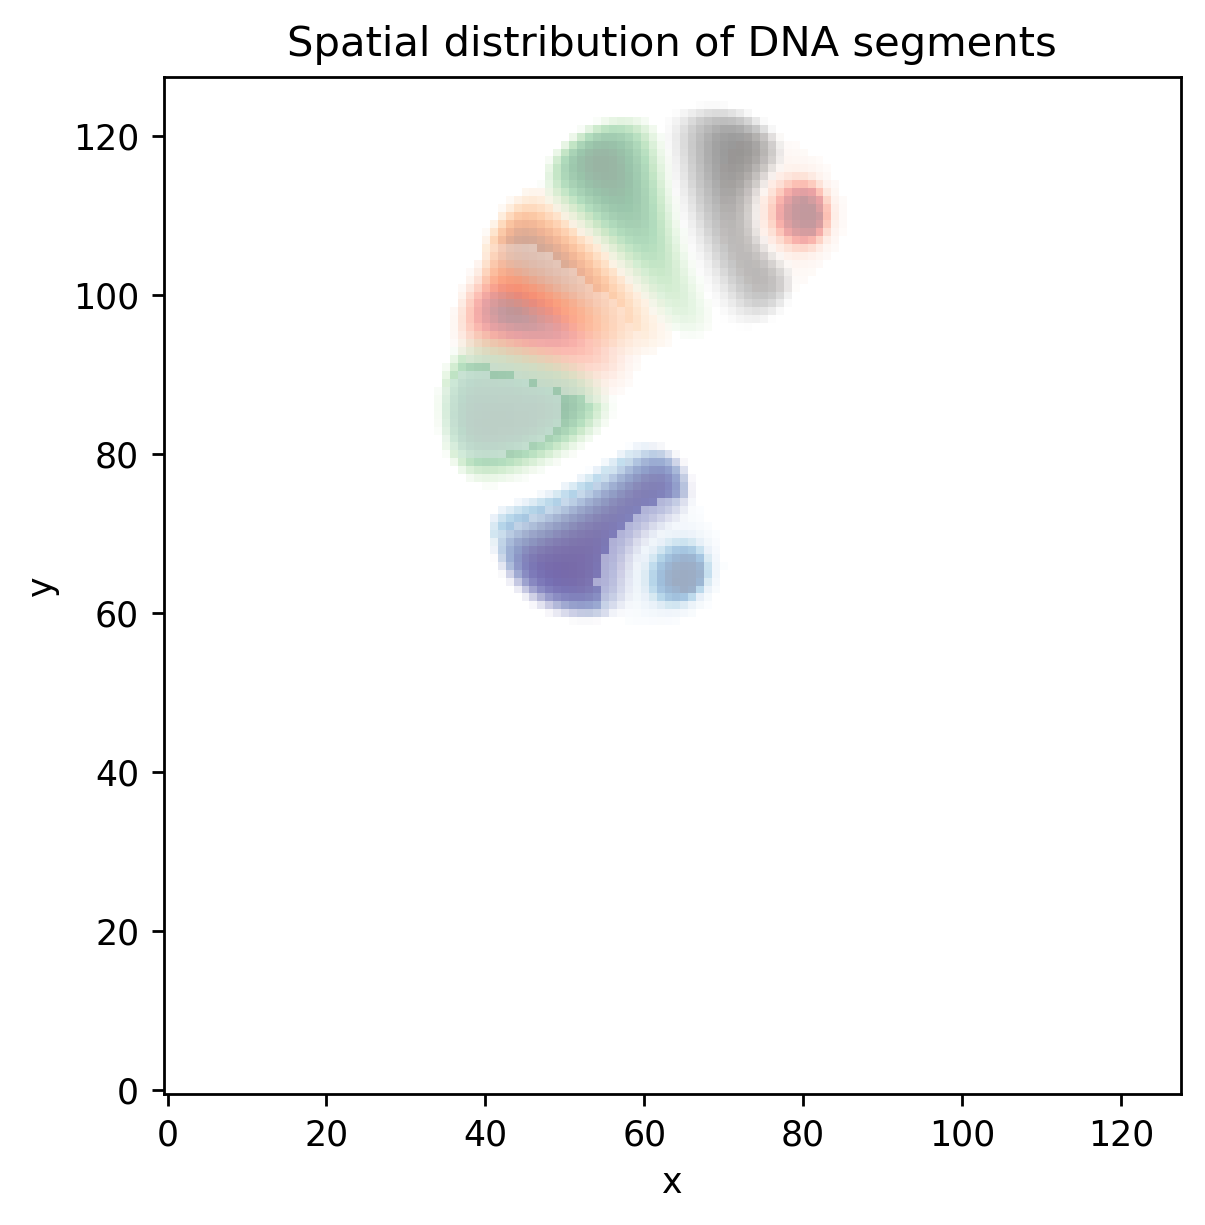

In [16]:
plot_phi_blocks_periodic(phi_block_pick, percentile=98)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def _threshold_by_mass_fraction(field2d, mass_fraction=0.1):
    flat = field2d.ravel()
    if flat.size == 0:
        return np.inf
    total = flat.sum()
    if total <= 0:
        return np.inf

    order = np.argsort(flat)[::-1]  # descending
    sorted_vals = flat[order]
    cumsum = np.cumsum(sorted_vals)

    target = mass_fraction * total
    idx = np.searchsorted(cumsum, target, side="left")
    idx = min(idx, len(sorted_vals) - 1)
    return sorted_vals[idx]


def plot_phi_blocks_dense_small_on_top(
    phi_blocks,
    dx=1.0, dy=1.0,
    Lx=None, Ly=None,
    labels=None,
    mode="fraction_of_mass",
    mass_fraction=0.1,
    percentile=95,
    relative_to_max=0.9,
    min_abs=None,
    transpose=True,
    ax=None,
    title="Dense component regions (small on top)",
):
    """
    Visualize dense regions of each component in phi_blocks with non-overlapping colors.

    Non-overlap rule:
        Each pixel is finally assigned to at most one component, but if multiple
        components are 'dense' there, the component whose dense area is smaller
        (global) wins (is drawn on top).

    Parameters
    ----------
    phi_blocks : ndarray, shape (n_comp, nx, ny)
        Component densities.
    mode : str
        How to define "dense" per component:
        - "fraction_of_mass": keep top pixels that contain given fraction of component mass.
        - "percentile": keep pixels above given percentile within each component.
        - "relative_to_max": keep pixels >= relative_to_max * max(component).
        - "argmax_only": ignore thresholds and just use argmax segmentation.
    min_abs : float or None
        Optional absolute floor to suppress noise (applied after the above mode).
    """

    phi_blocks = np.asarray(phi_blocks)
    n_comp, nx, ny = phi_blocks.shape

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    dense_masks = []

    if mode == "argmax_only":
        # classic winner-take-all, no small-on-top logic needed, but we still keep iface similar
        winner = np.argmax(phi_blocks, axis=0)
        for m in range(n_comp):
            mask = (winner == m)
            if min_abs is not None:
                mask &= (phi_blocks[m] >= min_abs)
            dense_masks.append(mask)
    else:
        # Threshold each component independently
        for m in range(n_comp):
            field = phi_blocks[m]

            if mode == "fraction_of_mass":
                thr = _threshold_by_mass_fraction(field, mass_fraction=mass_fraction)
                mask = field >= thr
            elif mode == "percentile":
                thr = np.percentile(field, percentile)
                mask = field >= thr
            elif mode == "relative_to_max":
                mx = field.max() if field.size else 0.0
                thr = relative_to_max * mx
                mask = field >= thr
            else:
                raise ValueError(f"Unknown mode: {mode}")

            if min_abs is not None:
                mask &= (field >= min_abs)

            dense_masks.append(mask)

    # Compute global dense area per component
    areas = np.array([mask.sum() for mask in dense_masks])

    # Order components from largest dense area to smallest
    # so that small components are drawn LAST and override larger ones.
    order = np.argsort(areas)[::-1]  # indices, largest -> smallest

    # Create label image, -1 is background
    label_img = -1 * np.ones((nx, ny), dtype=int)

    for m in order:
        mask = dense_masks[m]
        # small regions (processed last) will overwrite overlapping pixels
        label_img[mask] = m

    # Build colormap
    base = plt.get_cmap("tab10")
    colors = [base(i) for i in range(min(n_comp, 10))]
    if n_comp > 10:
        base2 = plt.get_cmap("tab20")
        colors += [base2(i) for i in range(n_comp - 10)]
    cmap = ListedColormap(colors[:n_comp])
    cmap.set_bad(alpha=0.0)

    # Mask background
    masked = np.ma.masked_where(label_img < 0, label_img)

    # Extent for physical coordinates
    if Lx is not None and Ly is not None:
        extent = [0, Lx, 0, Ly]
    else:
        extent = None

    to_plot = masked.T if transpose else masked
    ax.imshow(
        to_plot,
        origin="lower",
        cmap=cmap,
        interpolation="nearest",
        extent=extent,
    )

    # Legend
    if labels is None:
        labels = [f"comp {i}" for i in range(n_comp)]

    handles = [
        mpatches.Patch(color=colors[i], label=labels[i])
        for i in range(n_comp)
    ]
    ax.legend(handles=handles, loc="upper right", frameon=True)

    ax.set_title(title)
    ax.set_xlabel("x" if extent else "ix")
    ax.set_ylabel("y" if extent else "iy")

    return ax


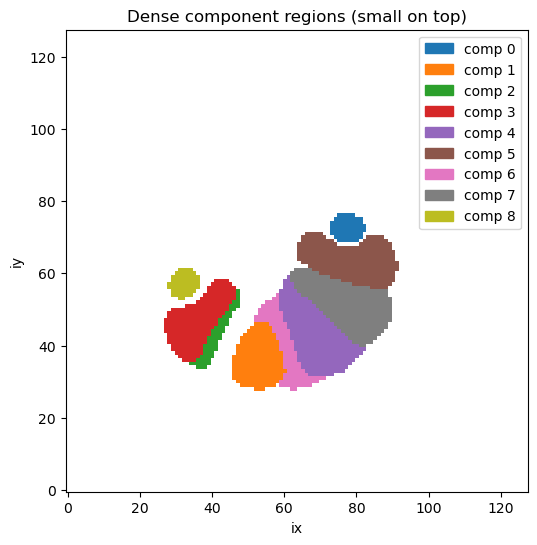

In [9]:
plot_phi_blocks_dense_small_on_top(
    phi_block_pick,
    mode="fraction_of_mass",   # good default for "most dense areas"
    mass_fraction=0.4,         # top 10% of each component mass
    min_abs=1e-6,              # optional noise floor
)
plt.show()

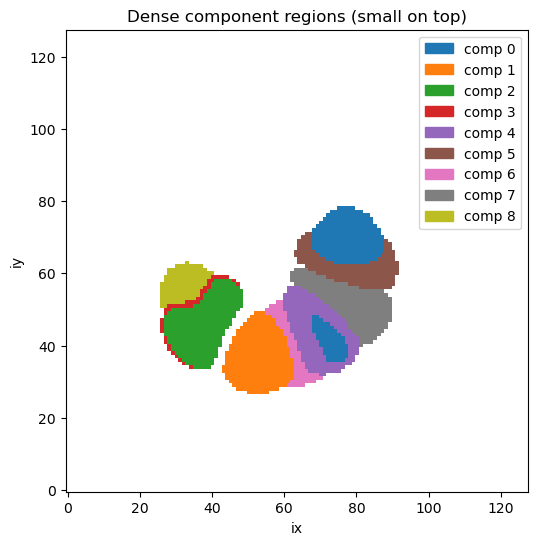

In [10]:
plot_phi_blocks_dense_small_on_top(
    phi_block_pick,
    mode="percentile",   # good default for "most dense areas"
    percentile=98,         # top 10% of each component mass
    min_abs=1e-6,              # optional noise floor
)
plt.show()

In [21]:
def gaussian_com_2d(phi):

    x_coord = np.arange(phi.shape[0])
    y_coord = np.arange(phi.shape[1])

    x_com = np.sum(x_coord * np.sum(phi, axis=1))/np.sum(phi)
    y_com = np.sum(y_coord * np.sum(phi, axis=0))/np.sum(phi)
    com = np.array([x_com, y_com])

    width_gaussian = phi.shape[0]/10

    x_coord = np.arange(phi.shape[0])
    y_coord = np.arange(phi.shape[1])
    X,Y = np.meshgrid(x_coord, y_coord, indexing='ij')
    gaussian = np.exp(-((X-com[0])**2 + (Y-com[1])**2)/width_gaussian)
    return gaussian

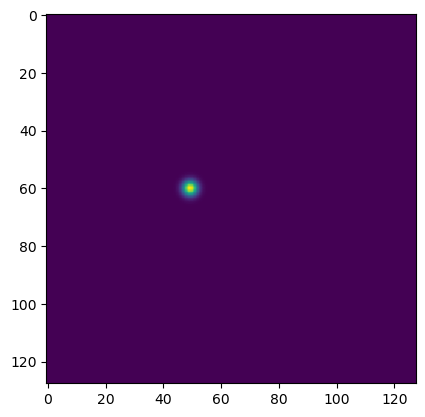

In [20]:
gaussian_dot = gaussian_com_2d(np.sum(phi_block_pick, axis = 0))
plt.imshow(gaussian_dot)

In [13]:
def radius_of_gyration(phi):
    x_coord = np.arange(phi.shape[0])
    y_coord = np.arange(phi.shape[1])

    x_com = np.sum(x_coord * np.sum(phi, axis=1))/np.sum(phi)
    y_com = np.sum(y_coord * np.sum(phi, axis=0))/np.sum(phi)
    com = np.array([x_com, y_com])

    x_distance_square_off_com = (x_coord - com[0])**2
    y_distance_square_off_com = (y_coord - com[1])**2
    distance_square_map = x_distance_square_off_com[:, None] + y_distance_square_off_com[None, :]

    rog = np.sqrt(np.sum(distance_square_map * phi)/np.sum(phi))
    return rog, com


rog, com = radius_of_gyration(np.sum(phi_block_pick, axis = 0))
print(rog)

22.256680517835967


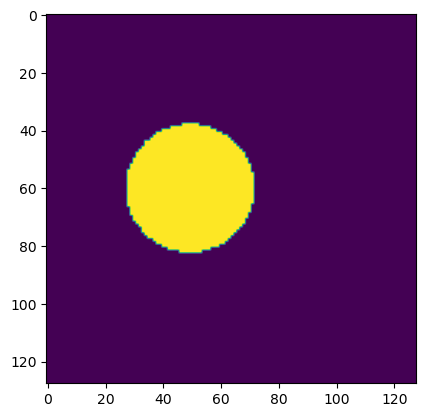

In [14]:
nx = phi_block_pick.shape[-2]
ny = phi_block_pick.shape[-1]
X,Y = np.meshgrid(np.arange(nx), np.arange(ny), indexing="ij")
circle = ((X-com[0])**2 + (Y-com[1])**2) < rog**2
plt.imshow(circle)

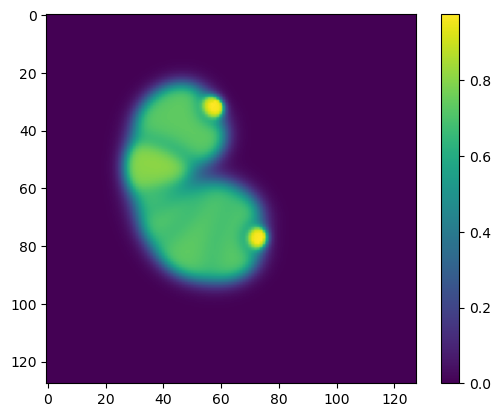

In [15]:
plt.imshow(np.sum(phi_block_pick, axis = 0))
plt.colorbar()